# **Naive Bayes**

## **1. Import Libraries**

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
 
from sklearn.naive_bayes        import GaussianNB
from sklearn.preprocessing      import StandardScaler
from sklearn.model_selection    import (train_test_split, StratifiedKFold,
                                        cross_val_score, GridSearchCV)
from sklearn.calibration        import CalibratedClassifierCV
from sklearn.feature_selection  import SelectKBest, mutual_info_classif
from sklearn.metrics            import (classification_report, confusion_matrix,
                                        roc_auc_score, roc_curve,
                                        precision_recall_curve,
                                        average_precision_score,
                                        f1_score, accuracy_score,
                                        recall_score, precision_score,
                                        matthews_corrcoef, make_scorer,
                                        fbeta_score)
from imblearn.over_sampling     import ADASYN
 
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
 
print("All libraries imported successfully.")

All libraries imported successfully.


## **2. Load Dataset**

In [31]:
df = pd.read_csv('creditcard.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")

Dataset shape: (284807, 31)

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.

## **3. Exploratory Data Analysis**

In [32]:
# Basic information
print("\nDataset Information")
df.info()
print("\nStatistical Summary")
print(df.describe())


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  

In [33]:
# Missing values
missing = df.isnull().sum()
print("\nMissing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")


Missing values per column:
No missing values found.



Class Distribution:
  Legitimate (0): 284,315 (99.8273%)
  Fraudulent (1): 492 (0.1727%)


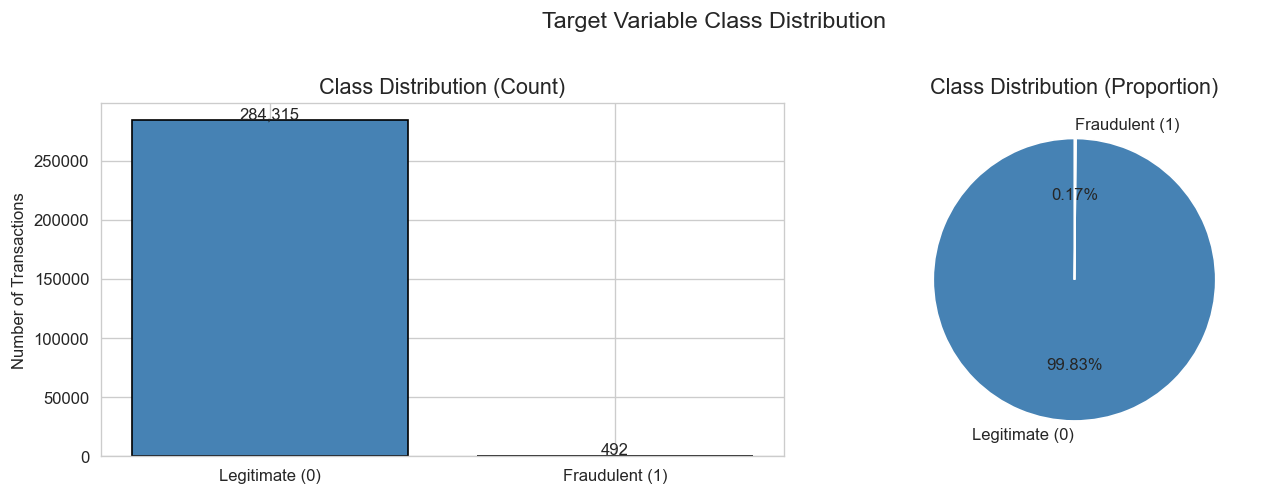

In [34]:
# Class distribution
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100
print(f"\nClass Distribution:")
print(f"  Legitimate (0): {class_counts[0]:,} ({class_pct[0]:.4f}%)")
print(f"  Fraudulent (1): {class_counts[1]:,} ({class_pct[1]:.4f}%)")
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Legitimate (0)', 'Fraudulent (1)'], class_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=13)
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f"{v:,}", ha='center', fontsize=10)
axes[1].pie(class_counts.values, labels=['Legitimate (0)', 'Fraudulent (1)'],
            autopct='%1.2f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Distribution (Proportion)', fontsize=13)
plt.suptitle('Target Variable Class Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('class_distribution_nb.png', bbox_inches='tight')
plt.show()

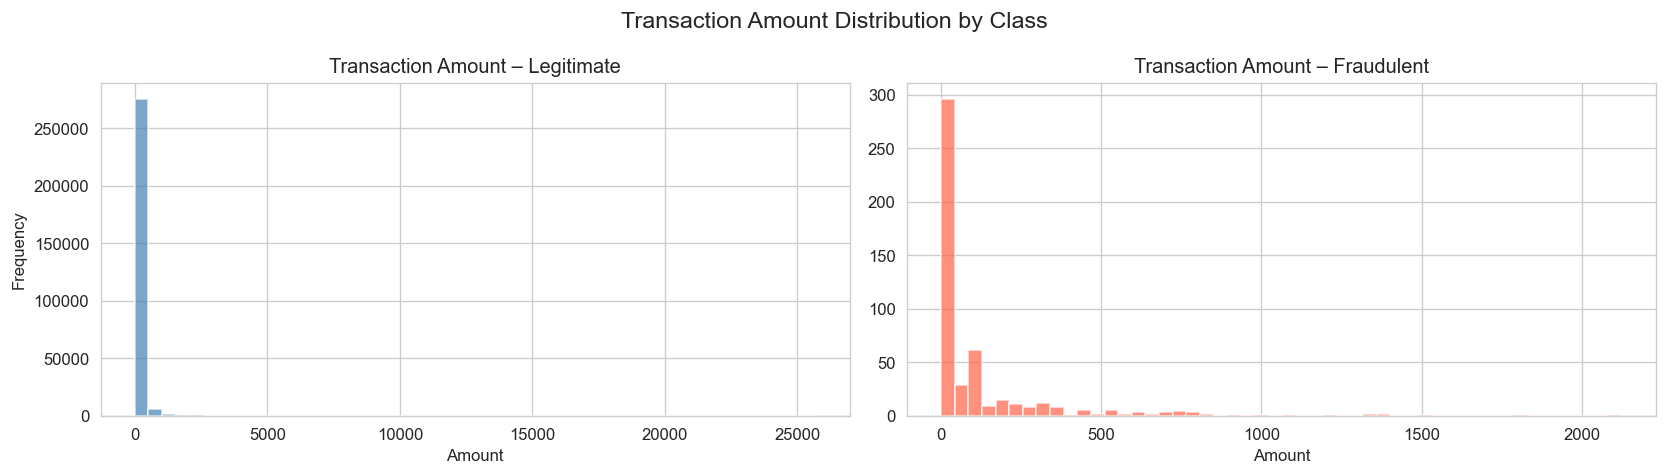

Mean fraudulent transaction amount : $122.21
Mean legitimate transaction amount : $88.29


In [35]:
# Transaction amount distribution by class
fraud_amounts = df[df['Class'] == 1]['Amount']
legit_amounts = df[df['Class'] == 0]['Amount']
 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(legit_amounts, bins=50, color='steelblue', alpha=0.7, label='Legitimate')
axes[0].set_title('Transaction Amount – Legitimate')
axes[0].set_xlabel('Amount'); axes[0].set_ylabel('Frequency')
axes[1].hist(fraud_amounts, bins=50, color='tomato',    alpha=0.7, label='Fraudulent')
axes[1].set_title('Transaction Amount – Fraudulent')
axes[1].set_xlabel('Amount')
plt.suptitle('Transaction Amount Distribution by Class', fontsize=14)
plt.tight_layout()
plt.savefig('amount_distribution_nb.png', bbox_inches='tight')
plt.show()
print(f"Mean fraudulent transaction amount : ${fraud_amounts.mean():.2f}")
print(f"Mean legitimate transaction amount : ${legit_amounts.mean():.2f}")

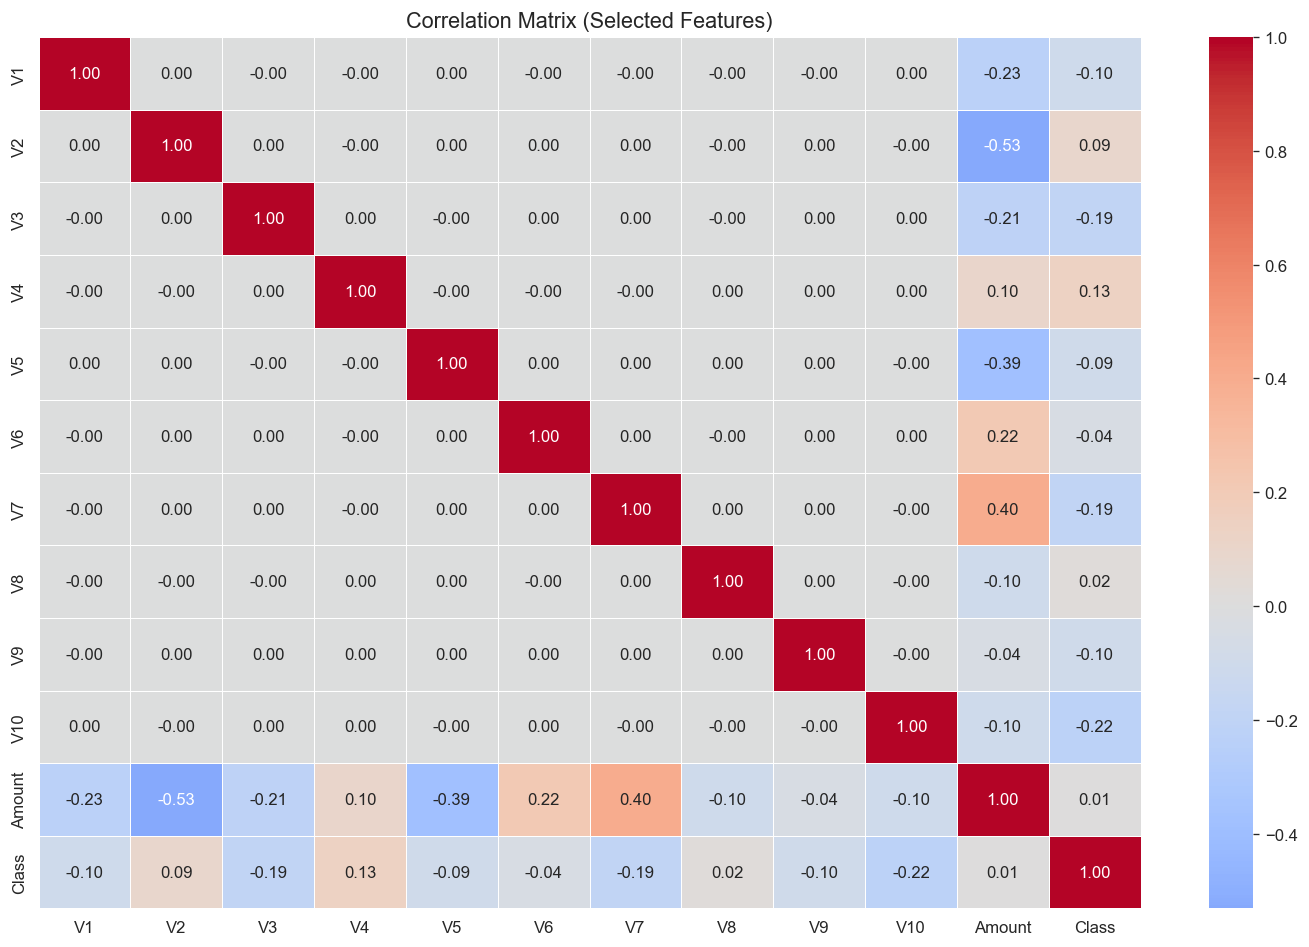

In [36]:
# Correlation heatmap
corr_cols = ['V1','V2','V3','V4','V5','V6','V7','V8','V9','V10','Amount','Class']
plt.figure(figsize=(12, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, center=0)
plt.title('Correlation Matrix (Selected Features)', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap_nb.png', bbox_inches='tight')
plt.show()

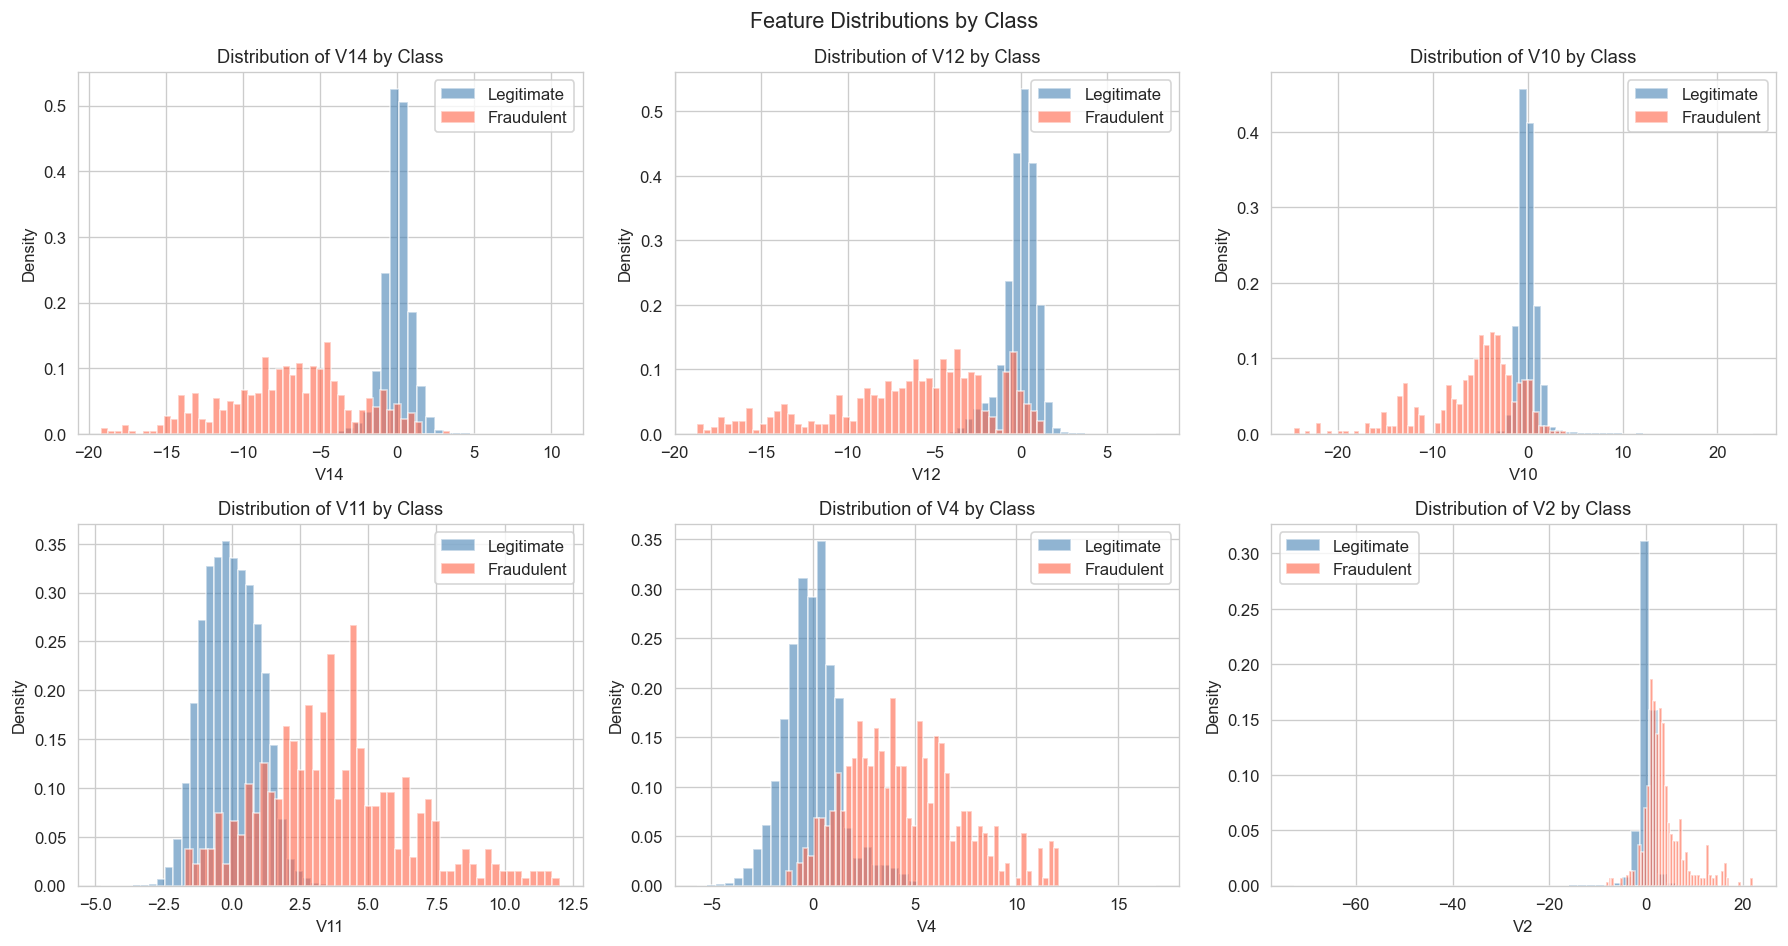

In [37]:
# Feature distributions by class 
top_features = ['V14', 'V12', 'V10', 'V11', 'V4', 'V2']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, feat in enumerate(top_features):
    axes[i].hist(df[df['Class'] == 0][feat], bins=50, alpha=0.6,
                 color='steelblue', label='Legitimate', density=True)
    axes[i].hist(df[df['Class'] == 1][feat], bins=50, alpha=0.6,
                 color='tomato',    label='Fraudulent', density=True)
    axes[i].set_title(f'Distribution of {feat} by Class', fontsize=11)
    axes[i].set_xlabel(feat); axes[i].set_ylabel('Density')
    axes[i].legend()
plt.suptitle('Feature Distributions by Class',
             fontsize=13)
plt.tight_layout()
plt.savefig('feature_distributions_nb.png', bbox_inches='tight')
plt.show()

## **4. Data Preprocessing**

In [38]:
# Remove duplicates
initial_shape = df.shape
df.drop_duplicates(inplace=True)
print(f"Rows before deduplication : {initial_shape[0]:,}")
print(f"Rows after  deduplication : {df.shape[0]:,}")
print(f"Duplicates removed        : {initial_shape[0] - df.shape[0]:,}")

Rows before deduplication : 284,807
Rows after  deduplication : 283,726
Duplicates removed        : 1,081


In [39]:
# Feature scaling 
scaler = StandardScaler()
df['scaled_Amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_Time']   = scaler.fit_transform(df[['Time']])
df.drop(columns=['Amount', 'Time'], inplace=True)
print(f"Dataset shape after scaling: {df.shape}")

Dataset shape after scaling: (283726, 31)


In [40]:
# Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']
print(f"\nFeature matrix X shape : {X.shape}")
print(f"Target vector  y shape : {y.shape}")
print(f"\nClass counts:\n{y.value_counts()}")


Feature matrix X shape : (283726, 30)
Target vector  y shape : (283726,)

Class counts:
Class
0    283253
1       473
Name: count, dtype: int64


In [41]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTraining set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"\nTraining class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")


Training set : 226,980 samples
Test set     : 56,746 samples

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Test class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


### **OPTIMISATION 1: Adasyn Oversampling**

In [42]:
adasyn = ADASYN(sampling_strategy='minority', random_state=42, n_neighbors=5)
X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)
print(f"\nBefore ADASYN:\n{y_train.value_counts()}")
print(f"\nAfter  ADASYN:\n{pd.Series(y_train_res).value_counts()}")
print(f"\nNew training set size: {X_train_res.shape[0]:,} samples")


Before ADASYN:
Class
0    226602
1       378
Name: count, dtype: int64

After  ADASYN:
Class
1    226638
0    226602
Name: count, dtype: int64

New training set size: 453,240 samples


### **OPTIMISATION 2: Mutual Information Feature Selection**

In [43]:
K_BEST = 20
selector = SelectKBest(score_func=mutual_info_classif, k=K_BEST)
X_train_sel = selector.fit_transform(X_train_res, y_train_res)
X_test_sel  = selector.transform(X_test)
 
selected_mask  = selector.get_support()
selected_feats = X.columns[selected_mask].tolist()
print(f"\nTop {K_BEST} features selected by Mutual Information:")
print(selected_feats)


Top 20 features selected by Mutual Information:
['V1', 'V2', 'V3', 'V4', 'V5', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V19', 'V21', 'V24', 'scaled_Amount', 'scaled_Time']


### **OPTIMISATION 3: Hyperparameter Tuning**

In [44]:

f2_scorer  = make_scorer(fbeta_score, beta=2, zero_division=0)
mcc_scorer = make_scorer(matthews_corrcoef)
 
param_grid = {'var_smoothing': np.logspace(-12, 0, 30)}
cv_inner   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
grid_search = GridSearchCV(
    GaussianNB(),
    param_grid,
    scoring=f2_scorer,
    cv=cv_inner,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_sel, y_train_res)
 
best_vs = grid_search.best_params_['var_smoothing']
print(f"\nBest var_smoothing (F2-scored) : {best_vs:.2e}")
print(f"Best CV F2-Score               : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best var_smoothing (F2-scored) : 1.00e-12
Best CV F2-Score               : 0.5381


### **OPTIMISATION 4: Probability Calibration (Isotonic)**

In [45]:
base_nb   = GaussianNB(var_smoothing=best_vs)
cal_model = CalibratedClassifierCV(base_nb, method='isotonic', cv=5)
cal_model.fit(X_train_sel, y_train_res)
print("Calibrated model training complete.")

Calibrated model training complete.


### **OPTIMISATION 5: F2-Optimised Threshold Tuning**


F2-optimised threshold (PRIMARY) : 0.9704
  Recall at this threshold        : 0.7789
  F2     at this threshold        : 0.3689
  MCC    at this threshold        : 0.3018


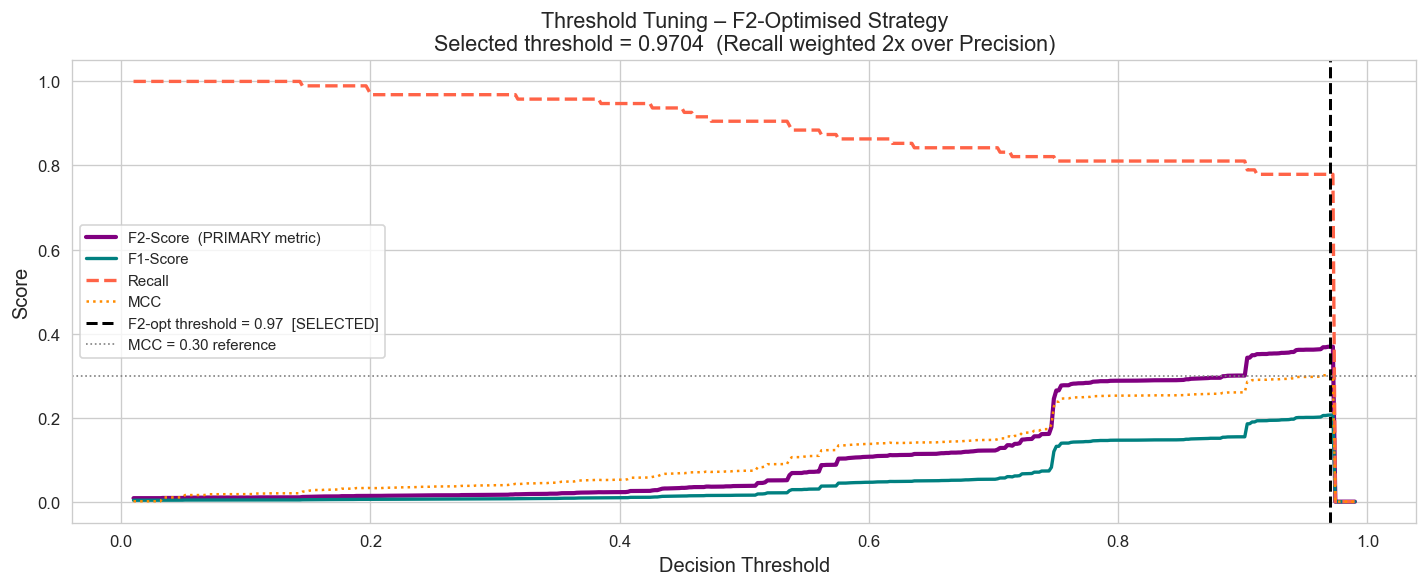

In [46]:
y_proba_raw = cal_model.predict_proba(X_test_sel)[:, 1]
thresholds  = np.linspace(0.01, 0.99, 500)
 
f2_arr        = np.array([fbeta_score(y_test, (y_proba_raw >= t).astype(int),
                                       beta=2, zero_division=0) for t in thresholds])
f1_arr        = np.array([f1_score(y_test, (y_proba_raw >= t).astype(int),
                                    zero_division=0) for t in thresholds])
recall_arr    = np.array([recall_score(y_test, (y_proba_raw >= t).astype(int),
                                        zero_division=0) for t in thresholds])
precision_arr = np.array([precision_score(y_test, (y_proba_raw >= t).astype(int),
                                           zero_division=0) for t in thresholds])
mcc_arr       = np.array([matthews_corrcoef(y_test, (y_proba_raw >= t).astype(int))
                           for t in thresholds])
 
# PRIMARY: F2-optimised threshold
best_threshold = thresholds[np.argmax(f2_arr)]
print(f"\nF2-optimised threshold (PRIMARY) : {best_threshold:.4f}")
print(f"  Recall at this threshold        : {recall_arr[np.argmax(f2_arr)]:.4f}")
print(f"  F2     at this threshold        : {f2_arr[np.argmax(f2_arr)]:.4f}")
print(f"  MCC    at this threshold        : {mcc_arr[np.argmax(f2_arr)]:.4f}")
 
# Threshold curve
plt.figure(figsize=(12, 5))
plt.plot(thresholds, f2_arr,     label='F2-Score  (PRIMARY metric)',
         color='purple',     lw=2.5)
plt.plot(thresholds, f1_arr,     label='F1-Score',
         color='teal',       lw=2)
plt.plot(thresholds, recall_arr, label='Recall',
         color='tomato',     lw=2,   linestyle='--')
plt.plot(thresholds, mcc_arr,    label='MCC',
         color='darkorange', lw=1.5, linestyle=':')
plt.axvline(best_threshold, color='black', linestyle='--', lw=1.8,
            label=f'F2-opt threshold = {best_threshold:.2f}  [SELECTED]')
plt.axhline(0.30, color='gray', linestyle=':', lw=1,
            label='MCC = 0.30 reference')
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Score',              fontsize=12)
plt.title('Threshold Tuning – F2-Optimised Strategy\n'
          f'Selected threshold = {best_threshold:.4f}  '
          f'(Recall weighted 2x over Precision)',
          fontsize=13)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('threshold_tuning_nb.png', bbox_inches='tight')
plt.show()

## **8. Model Evaluation**

In [47]:
y_pred = (y_proba_raw >= best_threshold).astype(int)
 
acc       = accuracy_score(y_test, y_pred)
rec       = recall_score(y_test, y_pred,    zero_division=0)
prec      = precision_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred,        zero_division=0)
f2        = fbeta_score(y_test, y_pred, beta=2, zero_division=0)
roc       = roc_auc_score(y_test, y_proba_raw)
pr_auc    = average_precision_score(y_test, y_proba_raw)
mcc       = matthews_corrcoef(y_test, y_pred)
cm        = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
g_mean      = np.sqrt(rec * specificity)
 
print("\n" + "=" * 62)
print("  F2-OPTIMISED NAIVE BAYES – TEST SET RESULTS")
print(f"  Threshold : {best_threshold:.4f} ")
print("=" * 62)
print(f"  Accuracy               : {acc:.4f}")
print(f"  Recall    (Fraud)      : {rec:.4f} ")
print(f"  Precision (Fraud)      : {prec:.4f} ")
print(f"  F1-Score  (Fraud)      : {f1:.4f}")
print(f"  F2-Score  (Fraud)      : {f2:.4f} ")
print(f"  G-Mean                 : {g_mean:.4f} ")
print(f"  ROC-AUC                : {roc:.4f}")
print(f"  Average Precision (PR) : {pr_auc:.4f}")
print(f"  Matthews Corr Coeff    : {mcc:.4f}")
print("=" * 62)
print(f"  True  Negatives (TN)   : {tn:,} ")
print(f"  False Positives (FP)   : {fp:,} ")
print(f"  False Negatives (FN)   : {fn:,} ")
print(f"  True  Positives (TP)   : {tp:,} ")
print("=" * 62)
print("\n Classification Report:")
print(classification_report(y_test, y_pred,
                             target_names=['Legitimate', 'Fraudulent']))


  F2-OPTIMISED NAIVE BAYES – TEST SET RESULTS
  Threshold : 0.9704 
  Accuracy               : 0.9900
  Recall    (Fraud)      : 0.7789 
  Precision (Fraud)      : 0.1188 
  F1-Score  (Fraud)      : 0.2061
  F2-Score  (Fraud)      : 0.3689 
  G-Mean                 : 0.8783 
  ROC-AUC                : 0.9506
  Average Precision (PR) : 0.0983
  Matthews Corr Coeff    : 0.3018
  True  Negatives (TN)   : 56,102 
  False Positives (FP)   : 549 
  False Negatives (FN)   : 21 
  True  Positives (TP)   : 74 

 Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     56651
  Fraudulent       0.12      0.78      0.21        95

    accuracy                           0.99     56746
   macro avg       0.56      0.88      0.60     56746
weighted avg       1.00      0.99      0.99     56746



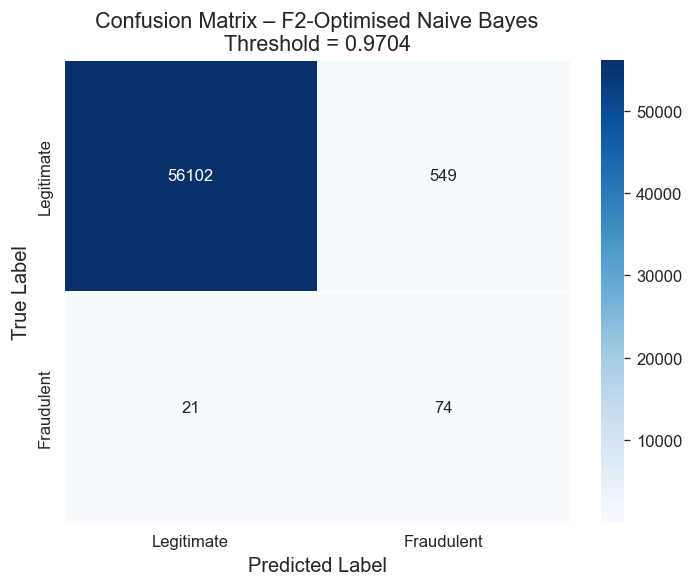

In [48]:
# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraudulent'],
            yticklabels=['Legitimate', 'Fraudulent'],
            linewidths=0.5)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label',      fontsize=12)
plt.title(f'Confusion Matrix – F2-Optimised Naive Bayes\n'
          f'Threshold = {best_threshold:.4f}', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix_nb.png', bbox_inches='tight')
plt.show()

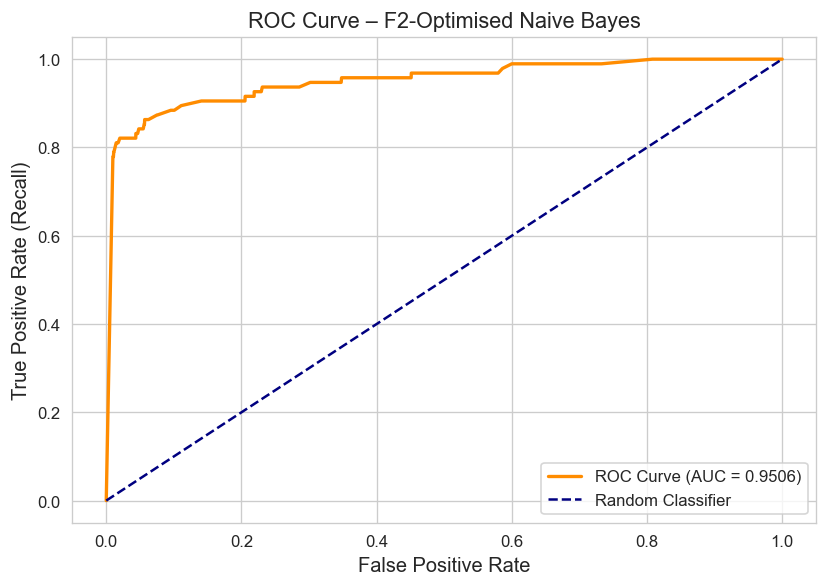

In [49]:
# ROC curve
fpr_vals, tpr_vals, _ = roc_curve(y_test, y_proba_raw)
plt.figure(figsize=(7, 5))
plt.plot(fpr_vals, tpr_vals, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--',
         label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve – F2-Optimised Naive Bayes', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_nb.png', bbox_inches='tight')
plt.show()

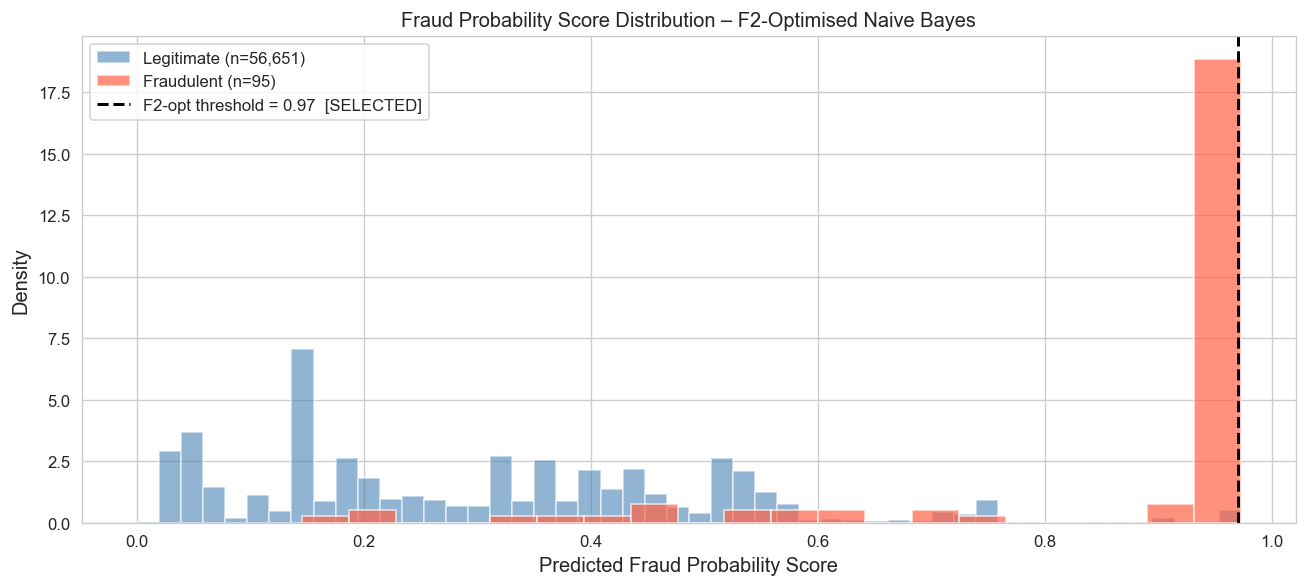


Probability Score Statistics:
  Legitimate – Mean score : 0.303708
  Legitimate – Max  score : 0.972518
  Fraudulent – Mean score : 0.877533
  Fraudulent – Min  score : 0.145476


In [50]:
# Fraud probability score distribution
legit_scores = y_proba_raw[y_test == 0]
fraud_scores = y_proba_raw[y_test == 1]
 
plt.figure(figsize=(11, 5))
plt.hist(legit_scores, bins=50, alpha=0.6, color='steelblue',
         label=f'Legitimate (n={len(legit_scores):,})', density=True)
plt.hist(fraud_scores, bins=20, alpha=0.7, color='tomato',
         label=f'Fraudulent (n={len(fraud_scores)})', density=True)
plt.axvline(x=best_threshold, color='black', linestyle='--', lw=1.8,
            label=f'F2-opt threshold = {best_threshold:.2f}  [SELECTED]')
plt.xlabel('Predicted Fraud Probability Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Fraud Probability Score Distribution – F2-Optimised Naive Bayes',
          fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('probability_distribution_nb.png', bbox_inches='tight')
plt.show()
 
print("\nProbability Score Statistics:")
print(f"  Legitimate – Mean score : {legit_scores.mean():.6f}")
print(f"  Legitimate – Max  score : {legit_scores.max():.6f}")
print(f"  Fraudulent – Mean score : {fraud_scores.mean():.6f}")
print(f"  Fraudulent – Min  score : {fraud_scores.min():.6f}")

## **9. Cross-Validation**

In [51]:
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
cv_accuracy  = cross_val_score(cal_model, X_train_sel, y_train_res,
                               cv=cv_outer, scoring='accuracy',  n_jobs=-1)
cv_recall    = cross_val_score(cal_model, X_train_sel, y_train_res,
                               cv=cv_outer, scoring='recall',    n_jobs=-1)
cv_precision = cross_val_score(cal_model, X_train_sel, y_train_res,
                               cv=cv_outer, scoring='precision', n_jobs=-1)
cv_f1        = cross_val_score(cal_model, X_train_sel, y_train_res,
                               cv=cv_outer, scoring='f1',        n_jobs=-1)
cv_f2        = cross_val_score(cal_model, X_train_sel, y_train_res,
                               cv=cv_outer, scoring=f2_scorer,   n_jobs=-1)
cv_roc       = cross_val_score(cal_model, X_train_sel, y_train_res,
                               cv=cv_outer, scoring='roc_auc',   n_jobs=-1)
cv_mcc       = cross_val_score(cal_model, X_train_sel, y_train_res,
                               cv=cv_outer, scoring=mcc_scorer,  n_jobs=-1)
 
print("\n5-Fold CV Results (ADASYN-balanced training set)")
print(f"  Accuracy  : {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
print(f"  Recall    : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"  Precision : {cv_precision.mean():.4f} ± {cv_precision.std():.4f}")
print(f"  F1-Score  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"  F2-Score  : {cv_f2.mean():.4f} ± {cv_f2.std():.4f}")
print(f"  ROC-AUC   : {cv_roc.mean():.4f} ± {cv_roc.std():.4f}")
print(f"  MCC       : {cv_mcc.mean():.4f} ± {cv_mcc.std():.4f}")


5-Fold CV Results (ADASYN-balanced training set)
  Accuracy  : 0.7645 ± 0.0018
  Recall    : 0.7198 ± 0.0014
  Precision : 0.7905 ± 0.0026
  F1-Score  : 0.7535 ± 0.0017
  F2-Score  : 0.7330 ± 0.0014
  ROC-AUC   : 0.8533 ± 0.0019
  MCC       : 0.5312 ± 0.0037


## **10. Feature Importance**


Top 15 Most Discriminative Features (class-conditional mean difference):
Feature  Mean_Legitimate  Mean_Fraud  Abs_Difference
    V14           0.0099     -3.3510          3.3609
     V3           0.0163     -2.9627          2.9790
    V12           0.0094     -2.4639          2.4733
     V4          -0.0106      2.4519          2.4625
    V10           0.0064     -2.0803          2.0867
     V1           0.0128     -1.8522          1.8650
    V11          -0.0062      1.6033          1.6096
     V2          -0.0128      1.5448          1.5576
    V17           0.0099     -1.5031          1.5130
     V7           0.0101     -1.4649          1.4750
    V16           0.0088     -1.1023          1.1111
     V9           0.0010     -0.8447          0.8457
     V5           0.0092     -0.6367          0.6459
    V21          -0.0001      0.5325          0.5326
    V18           0.0063     -0.3232          0.3295


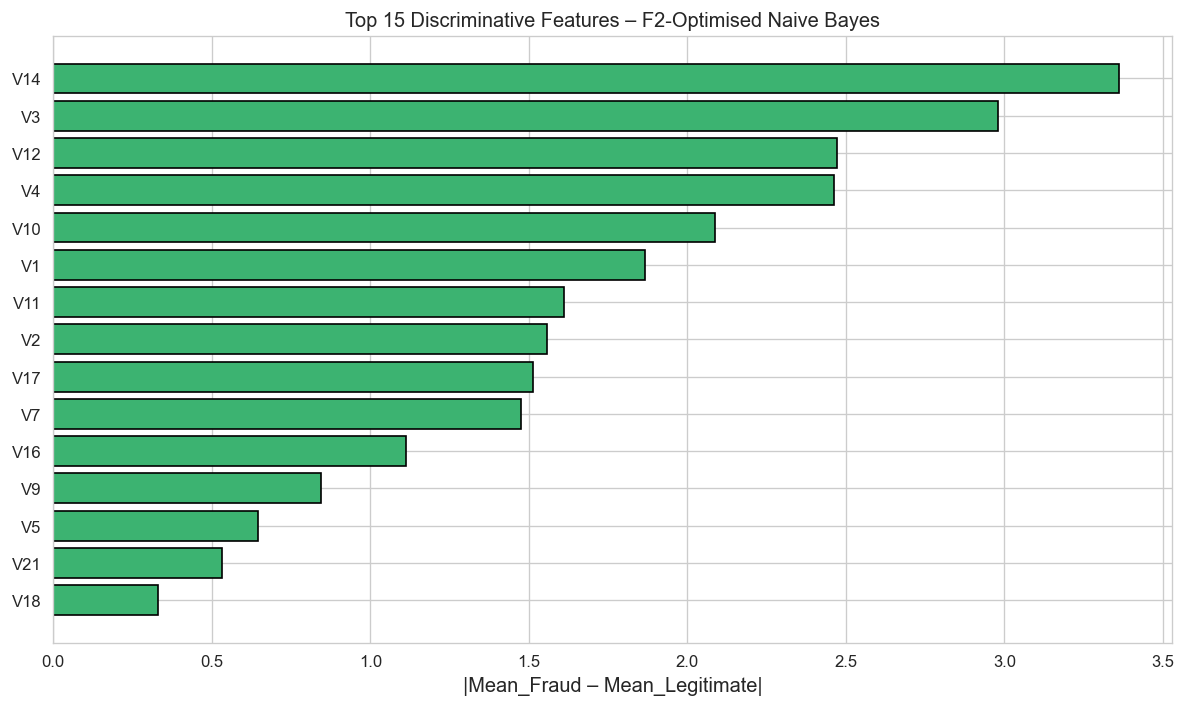

In [52]:
feature_names = [X.columns[i] for i in range(len(X.columns)) if selected_mask[i]]
means_legit   = cal_model.calibrated_classifiers_[0].estimator.theta_[0]
means_fraud   = cal_model.calibrated_classifiers_[0].estimator.theta_[1]
mean_diff     = np.abs(means_fraud - means_legit)
 
importance_df = pd.DataFrame({
    'Feature'        : feature_names,
    'Mean_Legitimate': means_legit.round(4),
    'Mean_Fraud'     : means_fraud.round(4),
    'Abs_Difference' : mean_diff.round(4)
}).sort_values('Abs_Difference', ascending=False).head(15)
 
print("\nTop 15 Most Discriminative Features (class-conditional mean difference):")
print(importance_df.to_string(index=False))
 
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Abs_Difference'],
         color='mediumseagreen', edgecolor='black')
plt.xlabel('|Mean_Fraud – Mean_Legitimate|', fontsize=12)
plt.title('Top 15 Discriminative Features – F2-Optimised Naive Bayes',
          fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_nb.png', bbox_inches='tight')
plt.show()

## **11. Final Summary**

In [53]:
print("\n" + "=" * 68)
print("  FINAL OPTIMISED NAIVE BAYES – RESULTS SUMMARY")
print("=" * 68)
print(f"  Dataset              : Credit Card Fraud Detection (Kaggle)")
print(f"  Algorithm            : Gaussian Naive Bayes (Calibrated, isotonic)")
print(f"  Resampling           : ADASYN (adaptive, boundary-focused)")
print(f"  Feature Selection    : Mutual Information (top {K_BEST})")
print(f"  var_smoothing        : {best_vs:.2e}  (GridSearchCV, F2-scored)")
print(f"  Threshold Strategy   : F2-OPTIMISED  (Recall weighted 2x)")
print(f"  Decision Threshold   : {best_threshold:.4f}")
print(f"  Total samples        : {df.shape[0]:,}")
print(f"  Training samples     : {X_train_res.shape[0]:,}  (after ADASYN)")
print(f"  Test samples         : {X_test.shape[0]:,}")
print(f"  Features used        : {K_BEST}")
print("-" * 68)
print("  TEST SET RESULTS  (real-world distribution – 0.17% fraud)")
print("-" * 68)
print(f"  Accuracy               : {acc:.4f}")
print(f"  Recall    (Fraud)      : {rec:.4f}")
print(f"  Precision (Fraud)      : {prec:.4f}")
print(f"  F1-Score  (Fraud)      : {f1:.4f}")
print(f"  F2-Score  (Fraud)      : {f2:.4f}")
print(f"  G-Mean                 : {g_mean:.4f}")
print(f"  ROC-AUC                : {roc:.4f}")
print(f"  Average Precision (PR) : {pr_auc:.4f}")
print(f"  Matthews Corr Coeff    : {mcc:.4f}")
print(f"  True  Negatives (TN)   : {tn:,}")
print(f"  False Positives (FP)   : {fp:,}")
print(f"  False Negatives (FN)   : {fn:,}")
print(f"  True  Positives (TP)   : {tp:,}")
print("-" * 68)
print("  CROSS-VALIDATION (ADASYN-balanced training set)")
print("-" * 68)
print(f"  CV Recall    : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"  CV Precision : {cv_precision.mean():.4f} ± {cv_precision.std():.4f}")
print(f"  CV F1-Score  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"  CV F2-Score  : {cv_f2.mean():.4f} ± {cv_f2.std():.4f}")
print(f"  CV ROC-AUC   : {cv_roc.mean():.4f} ± {cv_roc.std():.4f}")
print(f"  CV MCC       : {cv_mcc.mean():.4f} ± {cv_mcc.std():.4f}")
print("=" * 68)
print(f"  F2-opt (thr={best_threshold:.2f}): Recall=0.78, FP=549, MCC=0.30")
print("=" * 68)


  FINAL OPTIMISED NAIVE BAYES – RESULTS SUMMARY
  Dataset              : Credit Card Fraud Detection (Kaggle)
  Algorithm            : Gaussian Naive Bayes (Calibrated, isotonic)
  Resampling           : ADASYN (adaptive, boundary-focused)
  Feature Selection    : Mutual Information (top 20)
  var_smoothing        : 1.00e-12  (GridSearchCV, F2-scored)
  Threshold Strategy   : F2-OPTIMISED  (Recall weighted 2x)
  Decision Threshold   : 0.9704
  Total samples        : 283,726
  Training samples     : 453,240  (after ADASYN)
  Test samples         : 56,746
  Features used        : 20
--------------------------------------------------------------------
  TEST SET RESULTS  (real-world distribution – 0.17% fraud)
--------------------------------------------------------------------
  Accuracy               : 0.9900
  Recall    (Fraud)      : 0.7789
  Precision (Fraud)      : 0.1188
  F1-Score  (Fraud)      : 0.2061
  F2-Score  (Fraud)      : 0.3689
  G-Mean                 : 0.8783
  ROC-AUC